In [24]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import ast
import seaborn as sns

# Load the dataset and convert it to a pandas DataFrame
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean the date and time columns
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_posted_date'] = df['job_posted_date'].dt.tz_localize('UTC')
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else [skill_list])

In [25]:
df_DA_India = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_India = df_DA_India.dropna(subset='salary_year_avg')
df_DA_India_exploded = df_DA_India.explode('job_skills')

df_DA_skills = df_DA_India_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_DA_skills['skill_percent'] = ((df_DA_skills['skill_count'])/(len(df_DA_India))) * 100

skill_percent_threshhold = 5 #A minimum percentage set to categorize the various skills

# DataFrame containig the top most in-demand skills for Data Analysts in India
df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent_threshhold]

In [26]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()
df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))


In [27]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

In [28]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

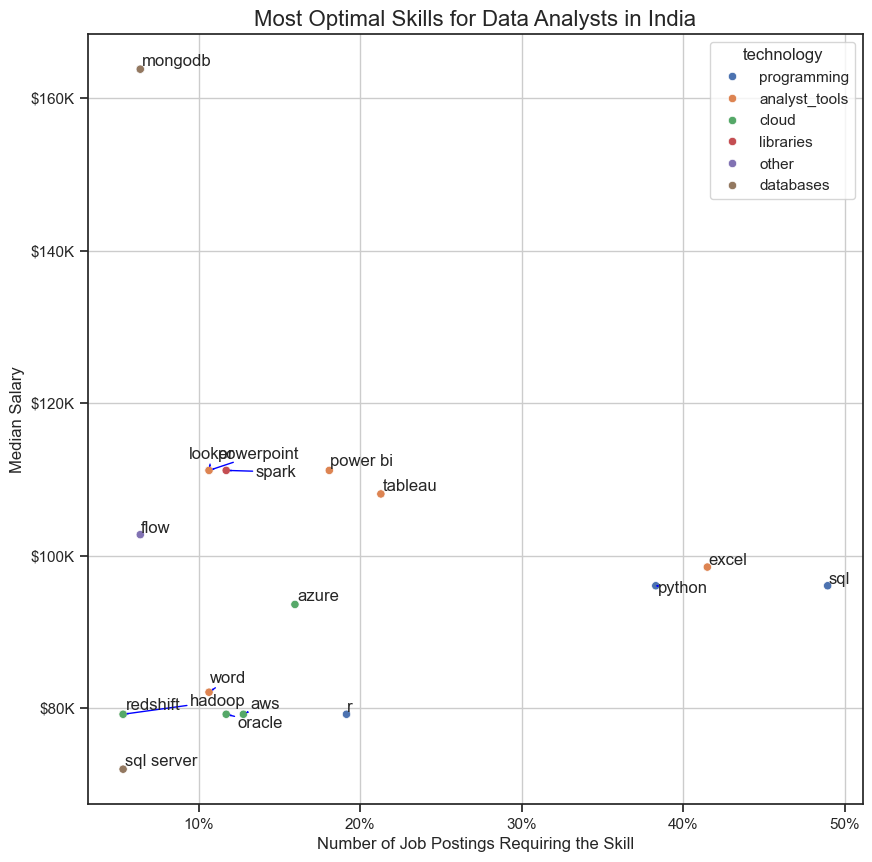

In [39]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

sns.scatterplot(
    data=df_plot,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)
sns.set_theme(style='whitegrid')

texts = []
for i, skill in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.annotate(skill, (df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i])))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='blue', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.title('Most Optimal Skills for Data Analysts in India', fontsize=16)
plt.xlabel('Number of Job Postings Requiring the Skill')
plt.ylabel('Median Salary')
plt.grid(True)
plt.show()